# Alpha geodesics on the space of Univariate Normal Distributions

Objective: visualise the geodesics induced by the alpha connections on the space of univariate normal distributions, and compare with the Fisher geodesic. 

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

import geomstats.backend as gs
from geomstats.information_geometry.normal import (
    UnivariateNormalAlpha,
    UnivariateNormalDistributions,
)

In [2]:
def plot_density(
    points,
    label=None,
    ax=None,
    x_min=-5.0,
    x_max=5.0,
    n=200,
    color="black",
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    x = np.linspace(x_min, x_max, n)

    for index, (mu, sigma) in enumerate(points):
        ax.plot(
            x,
            norm.pdf(x, mu, sigma),
            linestyle="--",
            linewidth=1,
            color=color,
            label=label if index == 0 else "",
        )
    return ax

## Data

In [3]:
riemannian_manifold = UnivariateNormalDistributions()

alpha_spaces = [
    UnivariateNormalDistributions(equip=False).equip_with_connection(
        UnivariateNormalAlpha,
        riemannian_manifold=riemannian_manifold,
        alpha=alpha,
    )
    for alpha in np.linspace(-1.0, 1.0, 21)
]

## Geodesics in the Density Space

### Boundary value problem

For the boundary value problem we consider two densities, parameterized by $(0., 1.)$ and $(5., 10.)$.

We show how geodesics look when we change $\alpha$.

In [4]:
start_point = gs.array([0.0, 1.0])
end_point = gs.array([5, 1.0])

fisher_geod_fnc = riemannian_manifold.connection.geodesic(
    start_point, end_point=end_point
)
geod_fncs = {
    space.connection.alpha: space.connection.geodesic(start_point, end_point=end_point)
    for space in alpha_spaces
}

In [5]:
time = gs.linspace(0.0, 1.0)

fisher_geod_points = fisher_geod_fnc(time)
geod_points = {alpha: geod_fnc(time) for alpha, geod_fnc in geod_fncs.items()}

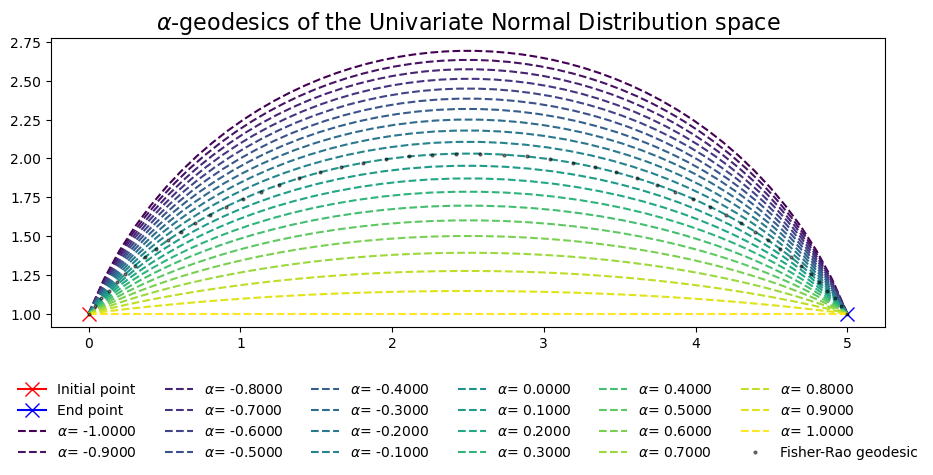

In [6]:
_, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    start_point[0],
    start_point[1],
    marker="x",
    markersize=10,
    color="red",
    label="Initial point",
)

ax.plot(
    end_point[0],
    end_point[1],
    marker="x",
    markersize=10,
    color="blue",
    label="End point",
)

colors = plt.cm.viridis(np.linspace(0, 1, len(geod_fncs.keys())))
for index, (alpha, points) in enumerate(geod_points.items()):
    ax.plot(
        points[:, 0],
        points[:, 1],
        linestyle="--",
        marker="None",
        color=colors[index],
        label=r"$\alpha$= " + f"{alpha:.4f}",
    )

point = fisher_geod_points
ax.plot(
    point[:, 0],
    point[:, 1],
    linestyle="None",
    marker="o",
    markersize=2,
    alpha=0.5,
    color="black",
    label="Fisher-Rao geodesic",
)

ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
ax.set_title(
    "$\\alpha$-geodesics of the Univariate Normal Distribution space", fontsize=16
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=math.ceil(len(labels) / 4),  # two rows
    frameon=False,
)
plt.tight_layout()
plt.show()

We have, for $\alpha =1$, 

$$\sigma(t)  =  \sqrt{\frac{1}{(1-t)\sigma_0 ^{-2} + t \sigma_1 ^{-2}}}$$
    
$$\mu(t) = \sigma(t)^2 \cdot [(1-t) \frac{\mu_0}{\sigma_0^2} + t \frac{\mu_1}{\sigma_1 ^2}] \\$$
so that when $\sigma_0 = \sigma_1$, the geodesic is a straight line ($\sigma(t)$ is constant) for this choice of parametrization. This is due to the fact that Gaussian distributions form an exponential family. In natural coordinates $(\Lambda(t),\eta(t))= (-\frac{1}{2\sigma ^2}(t),\frac{\mu}{\sigma^2}(t))$, the geodesics are straight lines. 

This is how the corresponding densities look like.

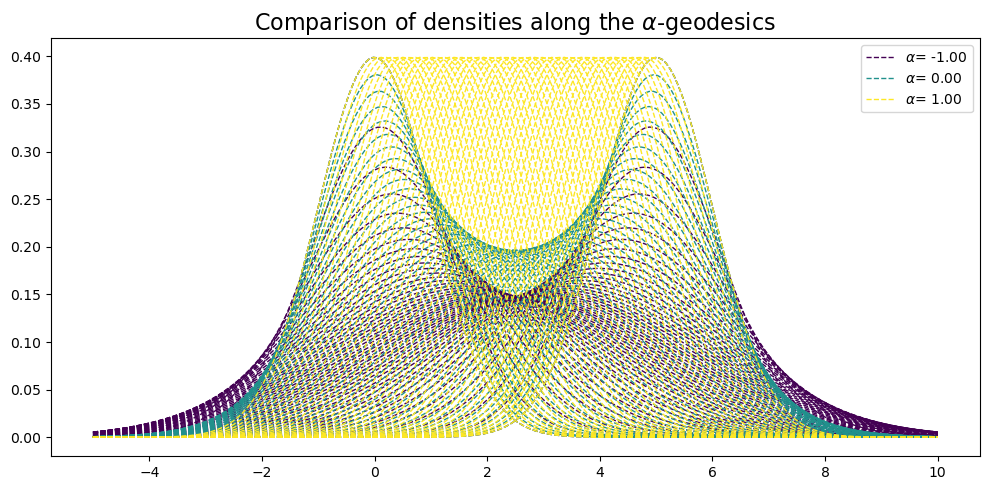

In [7]:
alphas = [-1.0, 0.0, 1.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(alphas)))

fig, ax = plt.subplots(figsize=(10, 5))

for index, alpha in enumerate(alphas):
    points = geod_points[alpha]
    plot_density(
        points,
        ax=ax,
        label="$\\alpha$= " + f"{alpha:.2f}",
        color=colors[index],
        x_min=-5.0,
        x_max=10.0,
    )

ax.set_title("Comparison of densities along the $\\alpha$-geodesics", fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

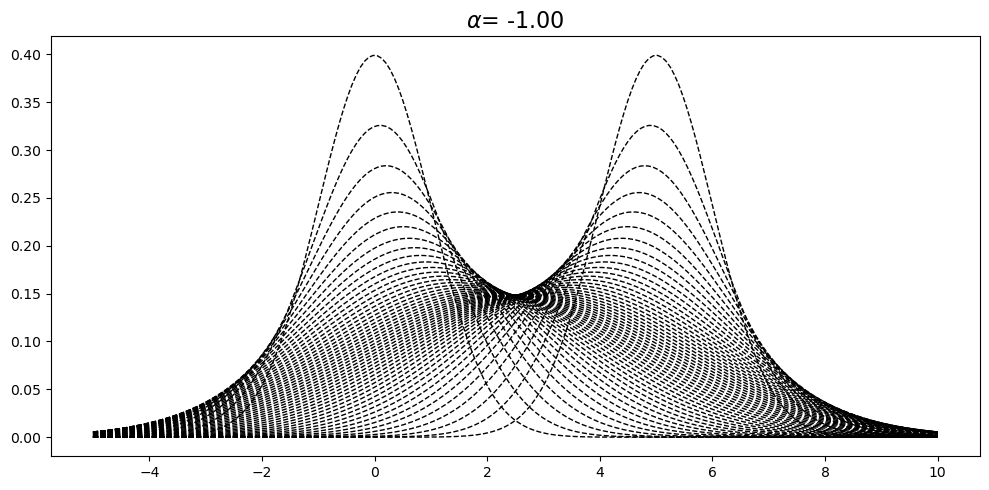

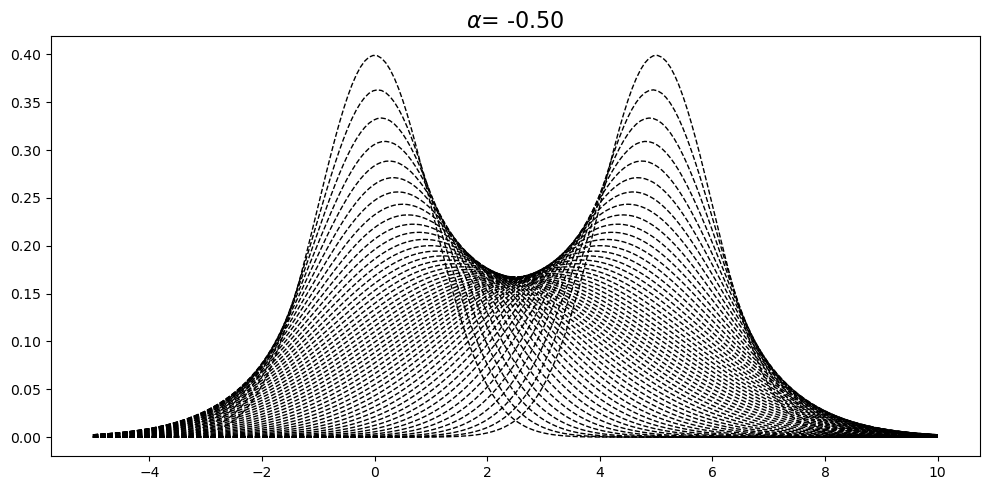

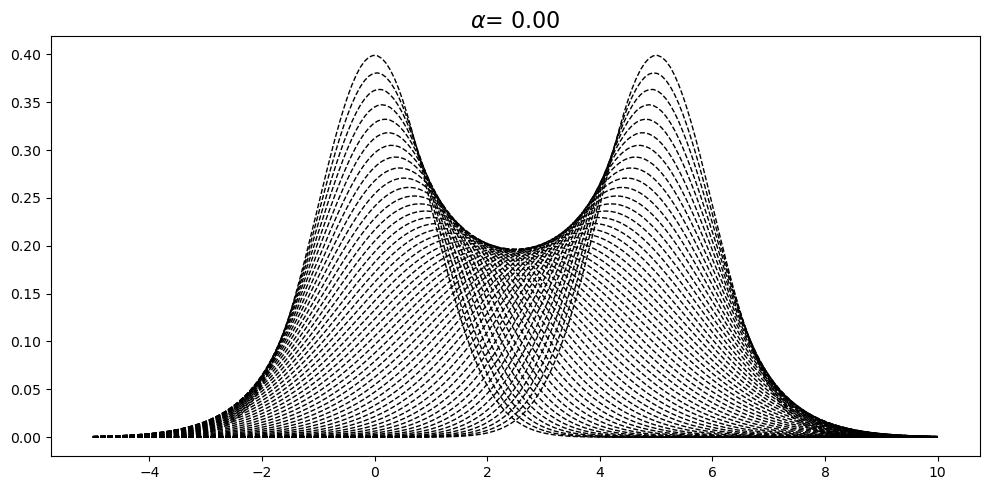

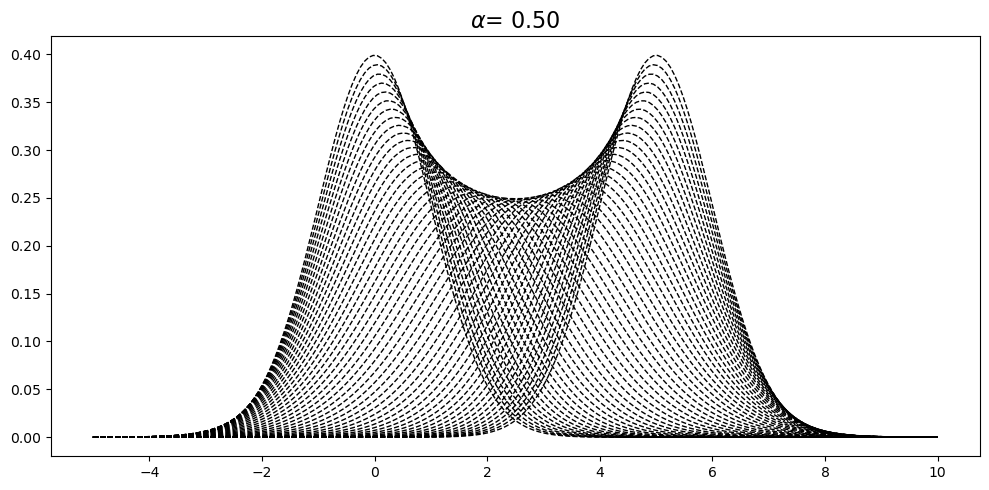

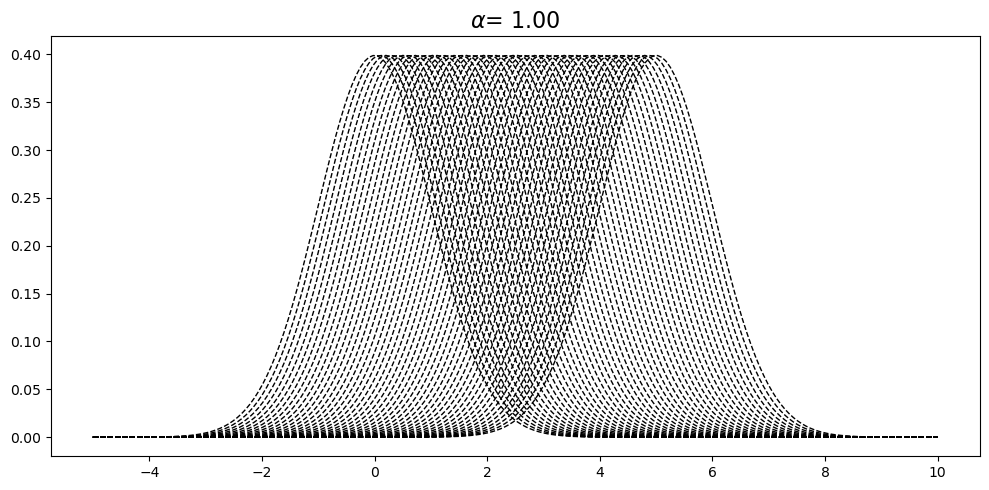

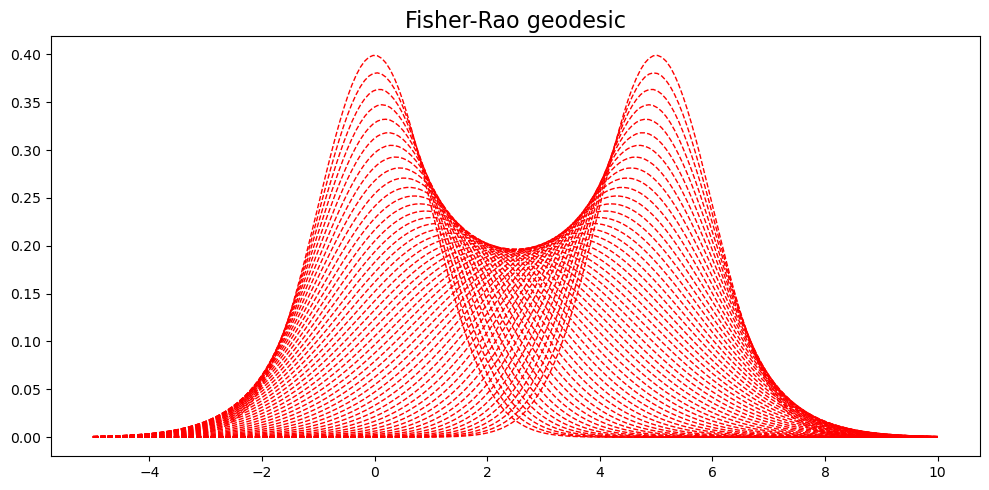

In [8]:
alphas = [-1.0, -0.5, 0.0, 0.5, 1.0]
for alpha in alphas:
    points = geod_points[alpha]
    ax = plot_density(
        points,
        x_min=-5.0,
        x_max=10.0,
    )

    ax.set_title("$\\alpha$= " + f"{alpha:.2f}", fontsize=16)

    plt.tight_layout()
    plt.show()


points = fisher_geod_points
ax = plot_density(
    points,
    color="red",
    x_min=-5.0,
    x_max=10.0,
)

ax.set_title("Fisher-Rao geodesic", fontsize=16)

plt.tight_layout()
plt.show()

### Initial value problem

In [9]:
start_point = gs.array([0.0, 1.0])
tangent_vec = gs.array([0.5, 0.4])

fisher_geod_fnc = riemannian_manifold.connection.geodesic(
    start_point, initial_tangent_vec=tangent_vec
)

geod_fncs = {
    space.connection.alpha: space.connection.geodesic(
        start_point, initial_tangent_vec=tangent_vec
    )
    for space in alpha_spaces
    if space.connection.alpha in [-1.0, -0.5, 0.0, 0.5, 1.0]
}

In [10]:
time = gs.linspace(0.0, 1.0, 10)

fisher_geod_points = fisher_geod_fnc(time)
geod_points = {alpha: geod_fnc(time) for alpha, geod_fnc in geod_fncs.items()}

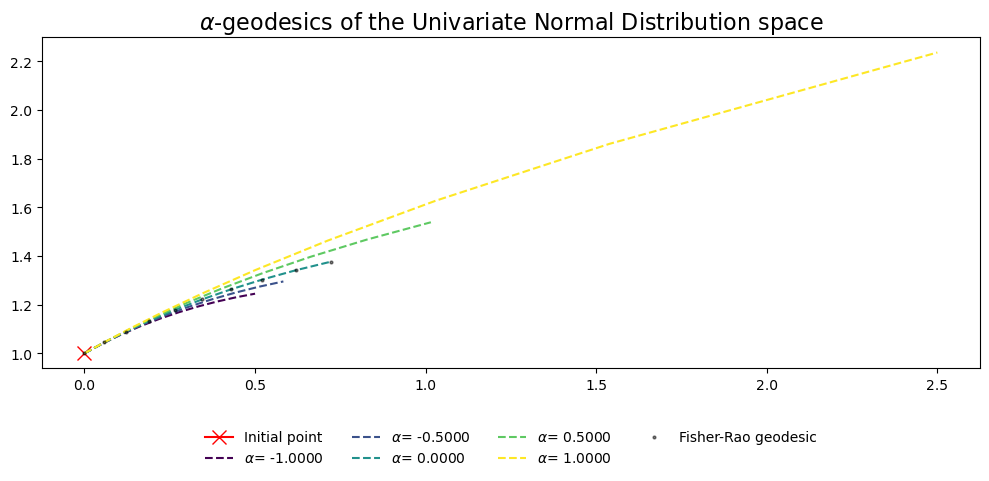

In [11]:
_, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    start_point[0],
    start_point[1],
    marker="x",
    markersize=10,
    color="red",
    label="Initial point",
)


colors = plt.cm.viridis(np.linspace(0, 1, len(geod_fncs.keys())))
for index, (alpha, points) in enumerate(geod_points.items()):
    ax.plot(
        points[:, 0],
        points[:, 1],
        linestyle="--",
        marker="None",
        color=colors[index],
        label=r"$\alpha$= " + f"{alpha:.4f}",
    )

point = fisher_geod_points
ax.plot(
    point[:, 0],
    point[:, 1],
    linestyle="None",
    marker="o",
    markersize=2,
    alpha=0.5,
    color="black",
    label="Fisher-Rao geodesic",
)

ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
ax.set_title(
    "$\\alpha$-geodesics of the Univariate Normal Distribution space", fontsize=16
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=math.ceil(len(labels) / 2),
    frameon=False,
)
plt.tight_layout()
plt.show()

The $\alpha=1$-geodesic seems to be a straight line, but it is not. The coordinates we introduced earlier apply here, and it is only in the parametrization with natural coordinates that we can actually observe straight lines for $1$-geodesics. 